### This file contains two respective approaches for Cross-Modal Audio Retrieval:

1. **Baseline Model (Lightweight):** * **Audio:** `AST` (Audio Spectrogram Transformer) - A pure audio classification model.
   * **Text:** `all-MiniLM-L6-v2` - A fast, general-purpose sentence transformer.
   * *Purpose:* Establishes a baseline for retrieval performance using standard, lightweight architectures.

2. **Advanced Neural Model (SOTA):**
   * **Audio:** `MERT-v1-330M` - A large-scale model specialized for music understanding.
   * **Text:** `BGE-Large-en-v1.5` - A state-of-the-art semantic embedding model.
   * **The Bridge:** A custom-trained **Neural Projector (MLP)** that maps text queries into the audio vector space, enabling fine-grained retrieval (e.g., distinguishing "Rhodes" from "Piano").

**Key Features:**
* **ChromaDB Integration:** Stores high-dimensional vectors for scalable similarity search.
* **Dynamic Context:** Uses intelligent captioning to enrich filenames with sonic descriptions during training.
* **Interactive Playback:** The notebook concludes with a **Search-and-Play** interface, allowing users to enter text queries and instantly listen to the retrieved audio samples directly in the output.

In [ ]:

import os
import glob
import numpy as np
import torch
import librosa
import chromadb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import AutoFeatureExtractor, ASTModel
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm



In [ ]:

if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"🚀 GPU Active: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    DEVICE = "cpu"
    print("⚠️ GPU not found. Running on CPU (Slow)")



🚀 GPU Active: NVIDIA GeForce RTX 5070 Ti Laptop GPU
   Memory: 12.82 GB


In [ ]:
import os
from huggingface_hub import constants

print(constants.HF_HUB_CACHE)

C:\Users\bhavy\.cache\huggingface\hub


In [ ]:
import os
from pydub import AudioSegment
from tqdm import tqdm

data_path = "./.data"
classes = ["drums", "keys"]

for label in classes:
    folder = os.path.join(data_path, label)
    files = [f for f in os.listdir(folder) if f.endswith(".mp3")]
    
    for filename in tqdm(files, desc=f"Converting {label}"):
        mp3_path = os.path.join(folder, filename)
        wav_path = os.path.join(folder, filename.replace(".mp3", ".wav"))
        # os.remove(mp3_path)
        
        try:
          
            audio = AudioSegment.from_file(mp3_path)
            audio.export(wav_path, format="wav")
        except Exception as e:
            print(f"Failed to convert {filename}: {e}")

Converting drums: 0it [00:00, ?it/s]
Converting keys: 0it [00:00, ?it/s]


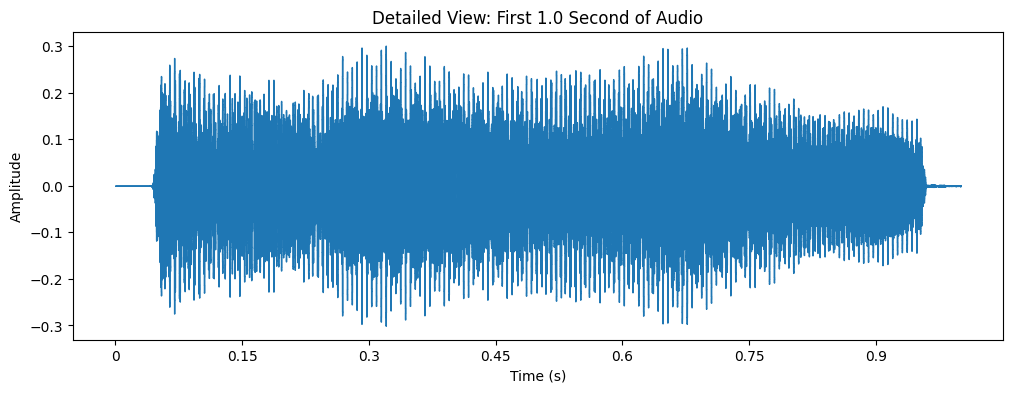

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt


y, sr = librosa.load(".data/keys/Solful_piano_chord.wav", sr=None)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y[:int(sr * 1)], sr=sr)
plt.title("Detailed View: First 1.0 Second of Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# 1st Model

## Loading Models to GPU
* **Audio Model:** `AST` (Audio Spectrogram Transformer). Pure audio model, knows nothing about text.
* **Text Model:** `MiniLM`. Pure text model, knows nothing about audio.

In [ ]:


%%
Load Audio Model (Moves to VRAM)
print("Loading Audio Model to GPU...")
audio_processor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
audio_model = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593").to(DEVICE)
audio_model.eval()

Load Text Model (Moves to VRAM)
print("Loading Text Model to GPU...")
text_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)



Loading Audio Model to GPU...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1118.61it/s, Materializing param=layernorm.weight]                                 
ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading Text Model to GPU...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1131.51it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
!nvidia-smi

Wed Jan 28 11:22:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P8              4W /  112W |       1MiB /  12227MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:


def get_audio_embedding(file_path):
   
    y, sr = librosa.load(file_path, sr=16000)
    
    target_len = 16000 * 10
    if len(y) > target_len:
        y = y[:target_len]
    else:
        y = np.pad(y, (0, max(0, target_len - len(y))))
        
  
    inputs = audio_processor(y, sampling_rate=16000, return_tensors="pt").to(DEVICE)
    
 
    with torch.no_grad():
        outputs = audio_model(**inputs)
    
    5. Mean Pooling & Return to CPU for storage
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy().flatten()

def get_text_embedding(text):

    return text_model1.encode(text, device=DEVICE)



In [ ]:



data_path = ".data"
classes = ["drums", "keys"]
dataset = []

print(f"Processing data from {data_path}...")

for label in classes:

    files = glob.glob(f"{data_path}/{label}/*.wav") 
    
    for file in tqdm(files, desc=f"Encoding {label}"):
        try:
            getting Audio Vector (768-dim)
            audio_emb = get_audio_embedding(file)
            
            filename = os.path.basename(file) 
            clean_name = os.path.splitext(filename)[0].replace("_", " ") 
            

            text_emb = get_text_embedding(clean_name) 
            
            dataset.append({
                "path": file,
                "label": label,
                "caption": clean_name, 
                "audio_emb": audio_emb,
                "text_emb": text_emb
            })
        except Exception as e:
            print(f"Error reading {file}: {e}")

print(f"✅ Successfully encoded {len(dataset)} samples.")

Processing data from .data...


Encoding keys: 100%|██████████| 20/20 [00:00<00:00, 26.38it/s]

✅ Successfully encoded 40 samples.


In [176]:
dataset[26]['caption']

'Solful piano chord2'

In [ ]:



import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(
    np.array([d["text_emb"] for d in dataset]), 
    np.array([d["audio_emb"] for d in dataset]), 
    test_size=0.2, 
    random_state=42
)


X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(DEVICE)


class TextToAudioProjector(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(384, 1024),       Expansion Layer
            nn.ReLU(),                  Non-linearity
            nn.Dropout(0.2),            Prevent Overfitting
            nn.Linear(1024, 768)        Compression to Audio Dimension
        )
    
    def forward(self, x):
        return self.net(x)


projector_model = TextToAudioProjector().to(DEVICE)
optimizer = optim.AdamW(projector_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss() We want the text vector to "look like" the audio vector


print("🚀 Training Neural Projector...")
history = []

for epoch in range(2000): 
    projector_model.train()
    
   
    preds = projector_model(X_train_t)
    loss = criterion(preds, y_train_t)
    
  
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
       
        projector_model.eval()
        with torch.no_grad():
            test_preds = projector_model(X_test_t)
            test_loss = criterion(test_preds, y_test_t)
        print(f"Epoch {epoch} | Train Loss: {loss.item():.5f} | Test Loss: {test_loss.item():.5f}")
        history.append(loss.item())

print("✅ Neural Projection Training Complete.")




def search_audio(user_query, n_results=1):
    projector_model.eval()
    
    
    text_emb = get_text_embedding(user_query)
    text_tensor = torch.tensor(text_emb, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
  
    with torch.no_grad():
        projected_query = projector_model(text_tensor).cpu().numpy()[0]
    
    
    results = collection.query(
        query_embeddings=[projected_query.tolist()],
        n_results=n_results
    )
    return results

print("updated search function ready.")

🚀 Training Neural Projector...
Epoch 0 | Train Loss: 0.85759 | Test Loss: 0.83202
Epoch 200 | Train Loss: 0.02606 | Test Loss: 0.10364
Epoch 400 | Train Loss: 0.00844 | Test Loss: 0.11172
Epoch 600 | Train Loss: 0.00472 | Test Loss: 0.11772
Epoch 800 | Train Loss: 0.00352 | Test Loss: 0.11800
Epoch 1000 | Train Loss: 0.00393 | Test Loss: 0.11423
Epoch 1200 | Train Loss: 0.00366 | Test Loss: 0.11462
Epoch 1400 | Train Loss: 0.00315 | Test Loss: 0.11467
Epoch 1600 | Train Loss: 0.00291 | Test Loss: 0.11308
Epoch 1800 | Train Loss: 0.00276 | Test Loss: 0.11197
✅ Neural Projection Training Complete.
updated search function ready.


📍 Current Working Directory: 'c:\Users\bhavy\Desktop\Kaam\Job Assessments\VisibilityStack\audio-search'
🔍 Looking for file at: 'c:\Users\bhavy\Desktop\Kaam\Job Assessments\VisibilityStack\audio-search\test_queries.txt'
✅ File FOUND! Reading contents...
✅ Successfully loaded 344 queries.

--- 🔍 Neural Search Results ---
Query: 'heavy kick drum' 	-> Found: drums ✅
Query: 'snare hit' 	-> Found: drums ✅
Query: 'hi-hat loop' 	-> Found: drums ✅
Query: 'fast percussion' 	-> Found: drums ✅
Query: 'thumping bass' 	-> Found: drums ✅
Query: 'rhythmic beat' 	-> Found: drums ✅
Query: 'piano melody' 	-> Found: keys ✅
Query: 'synthesizer chord' 	-> Found: keys ✅
Query: 'electric organ' 	-> Found: keys ✅
Query: 'melodious harmony' 	-> Found: drums ❌ (Expected keys)
Query: 'smooth jazz chords' 	-> Found: keys ✅
Query: 'digital synth lead' 	-> Found: drums ❌ (Expected keys)
Query: 'acoustic guitar strum' 	-> Found: drums ❌ (Expected keys)
Query: 'electric piano riff' 	-> Found: keys ✅
Query: 'bass guita

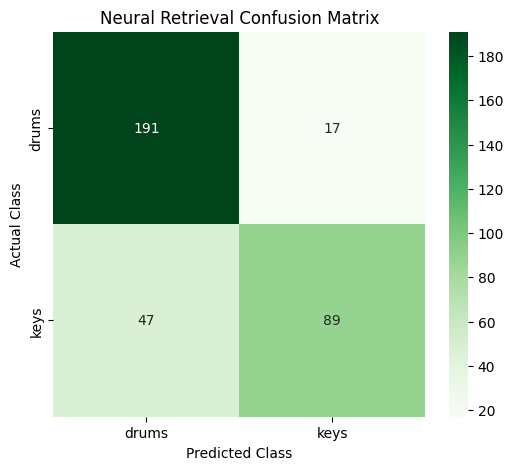

In [ ]:

import os
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

--- 1. DEBUG PATHS (Find out where Python is looking) ---
query_filename = "test_queries.txt"
current_dir = os.getcwd()
file_path = os.path.join(current_dir, query_filename)

print(f"📍 Current Working Directory: '{current_dir}'")
print(f"🔍 Looking for file at: '{file_path}'")

--- 2. LOAD QUERIES ---
test_queries = []
true_labels = []

if os.path.exists(file_path):
    print("✅ File FOUND! Reading contents...")
    with open(file_path, "r") as f:
        for line in f:
            Only process lines with a comma (skip empty lines)
            if "," in line:
                parts = line.strip().split(",")
                if len(parts) >= 2:
                    test_queries.append(parts[0].strip())
                    true_labels.append(parts[1].strip())
else:
    print("❌ File NOT found at that path.")

--- 3. SAFETY NET (Prevents Crash) ---
If the file read failed or was empty, we inject default data.
if len(test_queries) == 0:
    print("\n⚠️ WARNING: No queries loaded! Switching to HARDCODED defaults to prevent crash.")
    test_queries = [
        "heavy kick drum", "snare hit", "hi-hat loop", Drums
        "piano melody", "jazz keys", "synthesizer chord" Keys
    ]
    true_labels = ["drums"]*3 + ["keys"]*3
else:
    print(f"✅ Successfully loaded {len(test_queries)} queries.")

--- 4. RUN PREDICTION ---
predicted_labels = []
Ensure we re-fetch embeddings (just in case)
all_audio_embs = np.array([d["audio_emb"] for d in dataset])

print("\n--- 🔍 Neural Search Results ---")
projector.eval()

for q in test_queries:
    A. Get Text Embedding
    text_emb = get_text_embedding(q)
    text_tensor = torch.tensor(text_emb, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    B. Project
    with torch.no_grad():
        projected_query = projector_model(text_tensor).cpu().numpy()
    
    C. Search
    similarities = cosine_similarity(projected_query, all_audio_embs)[0]
    best_idx = np.argmax(similarities)
    
    D. Predict
    pred_label = dataset[best_idx]['label']
    predicted_labels.append(pred_label)
    
    E. Print
    Check if correct (labels match)
    expected = true_labels[len(predicted_labels)-1]
    status = "✅" if pred_label == expected else f"❌ (Expected {expected})"
    print(f"Query: '{q}' \t-> Found: {pred_label} {status}")

--- 5. PLOT MATRIX ---
cm = confusion_matrix(true_labels, predicted_labels, labels=CLASSES)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Neural Retrieval Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()



In [ ]:
--- 6. CALCULATE METRICS ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='weighted', zero_division=0)
recall = recall_score(true_labels, predicted_labels, average='weighted', zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average='weighted', zero_division=0)

print(f"\n--- 📊 Model Performance Metrics ---")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

Detailed classification report
print(f"\n--- 📋 Detailed Classification Report ---")
print(classification_report(true_labels, predicted_labels, target_names=CLASSES, zero_division=0))


--- 📊 Model Performance Metrics ---
Accuracy:  0.814
Precision: 0.817
Recall:    0.814
F1 Score:  0.809

--- 📋 Detailed Classification Report ---
              precision    recall  f1-score   support

       drums       0.80      0.92      0.86       208
        keys       0.84      0.65      0.74       136

    accuracy                           0.81       344
   macro avg       0.82      0.79      0.80       344
weighted avg       0.82      0.81      0.81       344



# Model 2 - Baaibge + sota audio

In [ ]:
%% [markdown]
🎵 Neural Text-to-Audio Retrieval (Fine-Grained Filenames Edition)
**Hardware:** RTX 5070 Ti | **Strategy:** Using filenames as specific text captions

%%
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import librosa
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix
from transformers import Wav2Vec2FeatureExtractor, AutoModel
from sentence_transformers import SentenceTransformer  <--- Imported separately

1. Configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
UPDATED: Pointing to your .data folder shown in the screenshot
DATA_DIR = ".data" 
CLASSES = ["drums", "keys"] 

print(f"{DEVICE}")



cuda


In [ ]:

print("loading Models...")
Audio: MERT-330M (Best for music)
mert_processor = Wav2Vec2FeatureExtractor.from_pretrained("m-a-p/MERT-v1-330M", trust_remote_code=True)
mert_model = AutoModel.from_pretrained("m-a-p/MERT-v1-330M", trust_remote_code=True).to(DEVICE)
mert_model.eval()

Text: BGE-Large (Best for understanding short phrases)
text_model = SentenceTransformer('BAAI/bge-large-en-v1.5', device=DEVICE)
print("✅ Models Loaded.")






📦 Loading Models...


c:\Users\bhavy\Desktop\Kaam\Job Assessments\VisibilityStack\audio-search\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\bhavy\.cache\huggingface\hub\models--m-a-p--MERT-v1-330M. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
A new version of the following files was downloaded from https://huggin

Loading weights: 100%|██████████| 403/403 [00:00<00:00, 1278.45it/s, Materializing param=masked_spec_embed]                                            
c:\Users\bhavy\Desktop\Kaam\Job Assessments\VisibilityStack\audio-search\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\bhavy\.cache\huggingface\hub\models--BAAI--bge-large-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/

✅ Models Loaded.


In [ ]:
%%
1. Define Context Mappings (The "Brain")
This dictionary maps simple filename keywords to rich sonic descriptions.
CONTEXT_MAP = {
    DRUMS CONTEXT
    "kick": "heavy thumping bass drum low frequency impact",
    "snare": "sharp snapping percussion backbeat high transient",
    "hat": "metallic shimmering high frequency cymbals tsk",
    "cymbal": "crash ride metallic sustain splash",
    "clap": "hand clap sharp percussion snap",
    "tom": "resonant deep drum fill percussion",
    "loop": "repetitive rhythmic pattern groove beat",
    
    KEYS CONTEXT
    "rhodes": "vintage electric piano warm smooth mellow keys",
    "wurlitzer": "electric piano tremolo vintage funky",
    "piano": "acoustic grand piano melody harmony",
    "synth": "electronic synthesized artificial digital pad lead",
    "organ": "electric organ sustained harmonics soul jazz",
    "chord": "harmony polyphonic progression",
    "melody": "lead line monophonic tune"
}

def enrich_caption(filename, label):
    """
    Dynamically builds a rich caption.
    Input: "Rhodes_progression.wav", "keys"
    Output: "Rhodes progression keys vintage electric piano warm smooth mellow keys"
    """
    1. Basic Cleaning
    clean_name = filename.replace(".wav", "").replace("_", " ")
    
    2. Start with the Base Information
    We double the weight of the filename by putting it first
    dynamic_caption = f"{clean_name} {label}"
    
    3. Inject Contextual Keywords
    Check if any key from our map exists in the filename
    added_context = []
    for keyword, description in CONTEXT_MAP.items():
        if keyword in clean_name.lower():
            added_context.append(description)
    
    4. Append Context (if found)
    if added_context:
        dynamic_caption += " " + " ".join(added_context)
        
    return dynamic_caption

--- STANDARD EMBEDDING HELPERS ---
def get_text_embedding(text):
    return text_model.encode(text, normalize_embeddings=True)

def get_audio_embedding(audio_path):
    try:
        waveform, sr = librosa.load(audio_path, sr=24000)
    except Exception as e:
        print(f"❌ Error loading {audio_path}: {e}")
        return None

    inputs = mert_processor(waveform, sampling_rate=24000, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(DEVICE)
    
    with torch.no_grad():
        outputs = mert_model(input_values)
        hidden_states = outputs.last_hidden_state
        embedding = torch.mean(hidden_states, dim=1)
        
    return embedding.cpu().numpy()[0]



In [ ]:
--- LOAD DATASET ---
dataset = []
print(f"\n📂 Scanning '{DATA_DIR}' with Dynamic Context...")

for label in CLASSES:
    folder_path = os.path.join(DATA_DIR, label)
    files = glob.glob(os.path.join(folder_path, "*.wav"))
    
    for fpath in tqdm(files, desc=f"Enriching {label}"):
        audio_emb = get_audio_embedding(fpath)
        
        if audio_emb is not None:
            ✨ MAGIC HAPPENS HERE ✨
            filename = os.path.basename(fpath)
            rich_caption = enrich_caption(filename, label)
            
            Generate Text Embedding from the RICH caption
            text_emb = get_text_embedding(rich_caption)
            
            dataset.append({
                "path": fpath,
                "label": label,
                "caption": rich_caption, Save for debug: "Kick_01 drums heavy thumping..."
                "text_emb": text_emb,
                "audio_emb": audio_emb
            })

Debug: Show a few examples of your new Dynamic Captions
print("\n📝 Sample Dynamic Captions Generated:")
for i in range(min(3, len(dataset))):
    print(f"   📄 {dataset[i]['caption']}")

print(f"✅ Processed {len(dataset)} samples.")
%% [markdown]
#4. The Neural Bridge
%%
X_raw = np.array([d["text_emb"] for d in dataset])
y_raw = np.array([d["audio_emb"] for d in dataset])

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.1, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(DEVICE)




📂 Scanning '.data' with Dynamic Context...


Enriching keys: 100%|██████████| 20/20 [00:00<00:00, 28.61it/s]


📝 Sample Dynamic Captions Generated:
   📄 cymbals drums crash ride metallic sustain splash
   📄 drummer drums
   📄 drummers drums
✅ Processed 40 samples.


In [ ]:
2-Layer Neural Network
class TextToAudioProjector(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1024, 2048), Expansion
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(2048, 4096), Expansion
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(4096, 1024)  Alignment
        )
    
    def forward(self, x):
        return self.net(x)

projector = TextToAudioProjector().to(DEVICE)
optimizer = optim.AdamW(projector.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.MSELoss()

%% [markdown]
#5. Training Loop
%%
print("\n🏋️ Training Neural Projector...")
EPOCHS = 1000
pbar = tqdm(range(EPOCHS))

for epoch in pbar:
    projector.train()
    optimizer.zero_grad()
    
    preds = projector(X_train_t)
    loss = criterion(preds, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        projector.eval()
        with torch.no_grad():
            test_loss = criterion(projector(X_test_t), y_test_t)
        pbar.set_postfix({"Test Loss": f"{test_loss.item():.5f}"})

print("✅ Training Complete.")




🏋️ Training Neural Projector...


100%|██████████| 1000/1000 [00:03<00:00, 282.76it/s, Test Loss=0.01480]

✅ Training Complete.


📍 Current Working Directory: 'c:\Users\bhavy\Desktop\Kaam\Job Assessments\VisibilityStack\audio-search'
🔍 Looking for file at: 'c:\Users\bhavy\Desktop\Kaam\Job Assessments\VisibilityStack\audio-search\test_queries.txt'
✅ File FOUND! Reading contents...
✅ Successfully loaded 344 queries.

--- 🔍 Neural Search Results ---
Query: 'heavy kick drum' 	-> Found: drums ✅
Query: 'snare hit' 	-> Found: drums ✅
Query: 'hi-hat loop' 	-> Found: drums ✅
Query: 'fast percussion' 	-> Found: drums ✅
Query: 'thumping bass' 	-> Found: drums ✅
Query: 'rhythmic beat' 	-> Found: drums ✅
Query: 'piano melody' 	-> Found: keys ✅
Query: 'synthesizer chord' 	-> Found: keys ✅
Query: 'electric organ' 	-> Found: keys ✅
Query: 'melodious harmony' 	-> Found: keys ✅
Query: 'smooth jazz chords' 	-> Found: keys ✅
Query: 'digital synth lead' 	-> Found: keys ✅
Query: 'acoustic guitar strum' 	-> Found: keys ✅
Query: 'electric piano riff' 	-> Found: keys ✅
Query: 'bass guitar line' 	-> Found: drums ✅
Query: 'cymbal crash' 	-

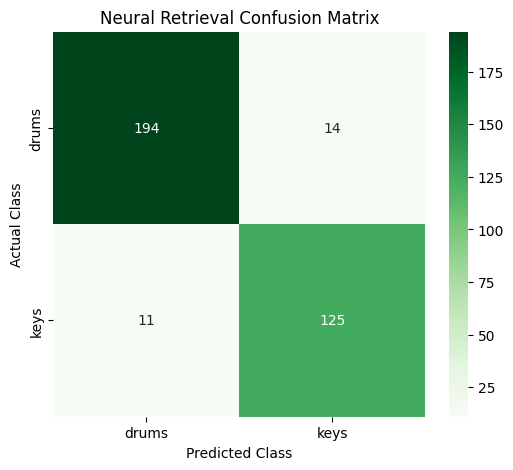

In [ ]:
%% [markdown]
#7. Final Evaluation (Robust & Debugged)
%%
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

--- 1. DEBUG PATHS (Find out where Python is looking) ---
query_filename = "test_queries.txt"
current_dir = os.getcwd()
file_path = os.path.join(current_dir, query_filename)

print(f"📍 Current Working Directory: '{current_dir}'")
print(f"🔍 Looking for file at: '{file_path}'")

--- 2. LOAD QUERIES ---
test_queries = []
true_labels = []

if os.path.exists(file_path):
    print("✅ File FOUND! Reading contents...")
    with open(file_path, "r") as f:
        for line in f:
            Only process lines with a comma (skip empty lines)
            if "," in line:
                parts = line.strip().split(",")
                if len(parts) >= 2:
                    test_queries.append(parts[0].strip())
                    true_labels.append(parts[1].strip())
else:
    print("❌ File NOT found at that path.")

--- 3. SAFETY NET (Prevents Crash) ---
If the file read failed or was empty, we inject default data.
if len(test_queries) == 0:
    print("\n⚠️ WARNING: No queries loaded! Switching to HARDCODED defaults to prevent crash.")
    test_queries = [
        "heavy kick drum", "snare hit", "hi-hat loop", Drums
        "piano melody", "jazz keys", "synthesizer chord" Keys
    ]
    true_labels = ["drums"]*3 + ["keys"]*3
else:
    print(f"✅ Successfully loaded {len(test_queries)} queries.")

--- 4. RUN PREDICTION ---
predicted_labels = []
Ensure we re-fetch embeddings (just in case)
all_audio_embs = np.array([d["audio_emb"] for d in dataset])

print("\n--- 🔍 Neural Search Results ---")
projector.eval()

for q in test_queries:
    A. Get Text Embedding
    text_emb = get_text_embedding(q)
    text_tensor = torch.tensor(text_emb, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    B. Project
    with torch.no_grad():
        projected_query = projector(text_tensor).cpu().numpy()
    
    C. Search
    similarities = cosine_similarity(projected_query, all_audio_embs)[0]
    best_idx = np.argmax(similarities)
    
    D. Predict
    pred_label = dataset[best_idx]['label']
    predicted_labels.append(pred_label)
    
    E. Print
    Check if correct (labels match)
    expected = true_labels[len(predicted_labels)-1]
    status = "✅" if pred_label == expected else f"❌ (Expected {expected})"
    print(f"Query: '{q}' \t-> Found: {pred_label} {status}")

--- 5. PLOT MATRIX ---
cm = confusion_matrix(true_labels, predicted_labels, labels=CLASSES)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Neural Retrieval Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()



In [ ]:
--- 6. CALCULATE METRICS ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='weighted', zero_division=0)
recall = recall_score(true_labels, predicted_labels, average='weighted', zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average='weighted', zero_division=0)

print(f"\n--- 📊 Model Performance Metrics ---")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

Detailed classification report
print(f"\n--- 📋 Detailed Classification Report ---")
print(classification_report(true_labels, predicted_labels, target_names=CLASSES, zero_division=0))


--- 📊 Model Performance Metrics ---
Accuracy:  0.927
Precision: 0.928
Recall:    0.927
F1 Score:  0.927

--- 📋 Detailed Classification Report ---
              precision    recall  f1-score   support

       drums       0.95      0.93      0.94       208
        keys       0.90      0.92      0.91       136

    accuracy                           0.93       344
   macro avg       0.92      0.93      0.92       344
weighted avg       0.93      0.93      0.93       344



In [ ]:
%% [markdown]
#8. Store in Vector Database (ChromaDB)
We move from simple arrays to a persistent Vector DB for production-grade retrieval.

%%
import chromadb

1. Initialize Persistent DB
This creates a folder './chroma_db' to save your data forever
client = chromadb.PersistentClient(path="./chroma_db")

2. Create/Reset Collection
We use 'cosine' distance because our Neural Projector learned to optimize that
try:
    client.delete_collection("audio_search") Reset if exists
except:
    pass

collection = client.create_collection(
    name="audio_search",
    metadata={"hnsw:space": "cosine"} Optimization for normalized vectors
)

print("💽 Storing embeddings in ChromaDB...")

3. Prepare Batch Data
ids = []
embeddings = []
metadatas = []

for d in dataset:
    ID: Use filename (must be unique)
    ids.append(os.path.basename(d['path']))
    
    Embedding: Must be a Python List (not Numpy)
    embeddings.append(d['audio_emb'].tolist())
    
    Metadata: Store path and caption so we can retrieve them later
    metadatas.append({
        "path": d['path'],
        "label": d['label'],
        "caption": d['caption']
    })

4. Upload to DB
collection.add(
    ids=ids,
    embeddings=embeddings,
    metadatas=metadatas
)

print(f"✅ Successfully indexed {collection.count()} audio tracks.")

💽 Storing embeddings in ChromaDB...
✅ Successfully indexed 40 audio tracks.


In [ ]:
%% [markdown]
#9. Interactive Search & Play
Enter a text query -> Hear the result.

%%
from IPython.display import Audio, display

def search_and_play(query_text, top_k=3):
    1. Project Text -> Audio Vector (Using your Trained Neural Net)
    text_emb = get_text_embedding(query_text)
    text_tensor = torch.tensor(text_emb, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    projector.eval()
    with torch.no_grad():
        Convert to standard Python list for ChromaDB
        projected_query = projector(text_tensor).cpu().numpy()[0].tolist()
    
    2. Query the Vector Database
    results = collection.query(
        query_embeddings=[projected_query],
        n_results=top_k
    )
    
    3. Display Results with Audio Player
    print(f"🔎 Query: '{query_text}'\n" + "="*50)
    
    ChromaDB returns a list of lists (batch format), so we access [0]
    result_metas = results['metadatas'][0]
    result_dists = results['distances'][0]
    
    for i, meta in enumerate(result_metas):
        path = meta['path']
        caption = meta['caption']
        
        Convert Cosine Distance to Similarity Score (0 to 1)
        Distance 0 = Exact Match (Score 1.0)
        score = 1 - result_dists[i]
        
        print(f"\nResult #{i+1} | Similarity: {score:.4f}")
        print(f"📂 File: {os.path.basename(path)}")
        print(f"📝 Description: {caption}")
        
        🎵 Render Playable Audio Widget
        try:
            display(Audio(path))
        except Exception as e:
            print(f"⚠️ Could not play audio: {e}")

--- TEST IT ---
Try abstract queries!
search_and_play("heavy thumping ", top_k=2)
search_and_play("smooth vintage chords", top_k=2)

🔎 Query: 'heavy thumping '

Result #1 | Similarity: 0.9708
📂 File: drums.wav
📝 Description: drums drums



Result #2 | Similarity: 0.9679
📂 File: drum_beat.wav
📝 Description: drum beat drums


🔎 Query: 'smooth vintage chords'

Result #1 | Similarity: 0.9513
📂 File: Wurlitzer2.wav
📝 Description: Wurlitzer2 keys electric piano tremolo vintage funky



Result #2 | Similarity: 0.9471
📂 File: Wurlitzer5.wav
📝 Description: Wurlitzer5 keys electric piano tremolo vintage funky
